In [25]:
from dotenv import load_dotenv
load_dotenv()
import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")

In [26]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    temperature=0.6
)

## **Output produce in Stream manner**

In [27]:
for chunk in llm.stream("write 1000 word paragraph about Agentic Ai"):  
    print(chunk.text(), end="")

The development and deployment of agentic AI systems represent a significant paradigm shift in the field of artificial intelligence, marking a transition from traditional reactive and proactive AI models to more autonomous, goal-oriented, and decision-making entities. Agentic AI refers to artificial intelligence systems that are capable of acting independently, making decisions based on their own goals or objectives, and exhibiting a form of agency that allows them to navigate complex environments with a degree of autonomy. This form of AI is not merely a tool that operates within predefined parameters set by humans; instead, it embodies a more sophisticated form of intelligence that can initiate actions, make choices, and adapt to changing circumstances in pursuit of its objectives.

The concept of agency in AI is derived from philosophy, where agency refers to the capacity of an entity to act independently and make decisions based on its own intentions. In the context of AI, agentic 

In [28]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")

C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
embedding_len = len(embeddings.embed_query("hello"))
embedding_len

768

## **Data ingestion**
[LLMs Powered autonomous agents](https://lilianweng.github.io/posts/2023-06-23-agent/)

In [30]:
url = "https://lilianweng.github.io/posts/2023-06-23-agent/"

from langchain_community.document_loaders import WebBaseLoader

web_load = WebBaseLoader(url)
data = web_load.load()

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [31]:
## check the actual data

data[0].page_content

'\n\n\n\n\n\nLLM Powered Autonomous Agents | Lil\'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLil\'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n|\n\n\n\n\n\n\nPosts\n\n\n\n\nArchive\n\n\n\n\nSearch\n\n\n\n\nTags\n\n\n\n\nFAQ\n\n\n\n\n\n\n\n\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\n \n\n\nTable of Contents\n\n\n\nAgent System Overview\n\nComponent One: Planning\n\nTask Decomposition\n\nSelf-Reflection\n\n\nComponent Two: Memory\n\nTypes of Memory\n\nMaximum Inner Product Search (MIPS)\n\n\nComponent Three: Tool Use\n\nCase Studies\n\nScientific Discovery Agent\n\nGenerative Agents Simulation\n\nProof-of-Concept Examples\n\n\nChallenges\n\nCitation\n\nReferences\n\n\n\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The

In [32]:
data[0].metadata

{'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/',
 'title': "LLM Powered Autonomous Agents | Lil'Log",
 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\

In [33]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 50
)

all_chunks = splitter.split_documents(documents=data)
len(all_chunks)

63

## **Extract data form the multiple URL or LIST of url**

In [34]:
url_list = [
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2020-04-07-the-transformer-family/"
]

In [35]:
docs = [WebBaseLoader(url).load() for url in url_list]
docs

[[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/', 'title': "Prompt Engineering | Lil'Log", 'description': 'Prompt Engineering, also known as In-Context Prompting, refers to methods for how to communicate with LLM to steer its behavior for desired outcomes without updating the model weights. It is an empirical science and the effect of prompt engineering methods can vary a lot among models, thus requiring heavy experimentation and heuristics.\nThis post only focuses on prompt engineering for autoregressive language models, so nothing with Cloze tests, image generation or multimodality models. At its core, the goal of prompt engineering is about alignment and model steerability. Check my previous post on controllable text generation.', 'language': 'en'}, page_content='\n\n\n\n\n\nPrompt Engineering | Lil\'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLil\'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n|\n\n\n\

In [36]:
bpe_token_text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size = 100,
    chunk_overlap = 25
)

## List compression

In [37]:
docs = [item for sublist in docs for item in sublist]
docs

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/', 'title': "Prompt Engineering | Lil'Log", 'description': 'Prompt Engineering, also known as In-Context Prompting, refers to methods for how to communicate with LLM to steer its behavior for desired outcomes without updating the model weights. It is an empirical science and the effect of prompt engineering methods can vary a lot among models, thus requiring heavy experimentation and heuristics.\nThis post only focuses on prompt engineering for autoregressive language models, so nothing with Cloze tests, image generation or multimodality models. At its core, the goal of prompt engineering is about alignment and model steerability. Check my previous post on controllable text generation.', 'language': 'en'}, page_content='\n\n\n\n\n\nPrompt Engineering | Lil\'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLil\'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n|\n\n\n\n

### ***BPE Embedding its Form OpenAI***
- since i've openai api key so i use `HF` embeddings so i use only the RecursiveCharTextSplitter only

In [38]:
prompt_n_transformer_docs = bpe_token_text_splitter.split_documents(documents=docs)

In [39]:
prompt_transformer_docs = splitter.split_documents(documents=docs)
len(prompt_transformer_docs)

99

## **Create Vector DB**

In [40]:
from langchain_community.vectorstores import Chroma

In [41]:
vectorstore_1 = Chroma.from_documents(
    documents= all_chunks,
    collection_name="autonomus-agent",
    embedding=embeddings


)

retriever_1 = vectorstore_1.as_retriever()

In [42]:
vectorstore_2 = Chroma.from_documents(
    documents=prompt_transformer_docs,
    embedding=embeddings,
    collection_name="prompt-transformer"
)

retriever_2 = vectorstore_2.as_retriever()

In [43]:

retriever_1.invoke("what do you mean be autonomus agent?")

[Document(metadata={'language': 'en', 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\n\nShort-term memory: I would consider all the in-context learning (See Prompt Engi

In [44]:
from langchain.tools.retriever import create_retriever_tool

In [45]:
retriever_tool_1 = create_retriever_tool(
    retriever=retriever_1,
    name="all about autonomous agent",
    description="LLM Powered Autonomous Agents related blog. and there have info about related to agent."
)

retriever_tool_2 = create_retriever_tool(
    retriever=retriever_2,
    name="prompt and transformer-tools",
    description="this tools have prompt and transformer related info."
)

In [52]:
tools = [retriever_tool_1, retriever_tool_2]

In [53]:
from langgraph.prebuilt import ToolNode


## **Start to building Agentic RAG**

In [48]:
from typing import TypedDict, Sequence, Literal, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages

In [49]:
class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [50]:
state = State(messages=[HumanMessage(content="hello how are you", name="Al amin", id=1)])
state

{'messages': [HumanMessage(content='hello how are you', additional_kwargs={}, response_metadata={}, name='Al amin', id='1')]}

In [54]:
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

In [81]:
response = llm_with_tools.invoke("why need position encoding is important in Transformer?")
response.tool_calls

[{'name': 'prompt and transformer-tools',
  'args': {'query': 'why position encoding is important in Transformer'},
  'id': 'tq4q54ezf',
  'type': 'tool_call'}]

In [82]:
response.tool_calls[0]['args']

{'query': 'why position encoding is important in Transformer'}

In [85]:
from langchain_core.messages import ToolMessage

retriever_tool_2.invoke(response.tool_calls[0])

ToolMessage(content="The architecture of the vanilla Transformer model. (Image source: Figure 17)\n\nPositional Encoding\nBecause self-attention operation is permutation invariant, it is important to use proper positional encodingto provide order information to the model. The positional encoding $\\mathbf{P} \\in \\mathbb{R}^{L \\times d}$ has the same dimension as the input embedding, so it can be added on the input directly. The vanilla Transformer considered two types of encodings:\n(1) Sinusoidal positional encoding is defined as follows, given the token position $i=1,\\dots,L$ and the dimension $\\delta=1,\\dots,d$:\n\n$$\n\\text{PE}(i,\\delta) = \n\\begin{cases}\n\\sin(\\frac{i}{10000^{2\\delta'/d}}) & \\text{if } \\delta = 2\\delta'\\\\\n\\cos(\\frac{i}{10000^{2\\delta'/d}}) & \\text{if } \\delta = 2\\delta' + 1\\\\\n\\end{cases}\n$$\n\nIn this way each dimension of the positional encoding corresponds to a sinusoid of different wavelengths in different dimensions, from $2\\pi$ t

In [134]:
def llm_decision_maker(state: State):
    print("--Call LLM decision maker---")
    question = state['messages'][-1].content
    response = llm_with_tools.invoke(question)
    
    return {
        "messages": [response]
    }

In [135]:
from langchain_core.prompts import PromptTemplate

class Grading(BaseModel):
    result: Annotated[Literal["pass", "fail"], Field(description="if the extract data is related to the user question the say 'pass' otherwise say 'fail'")]

llm_with_structured_op = llm.with_structured_output(Grading)

In [136]:
def grade_docs(state: State):
    print("---grade docs---")
    message = state['messages']
    last_messages = message[-1]
    question = message[0].content
    context = last_messages.content
    
    prompt=PromptTemplate(
        template="""You are a grader deciding if a document is relevant to a user’s question.
                    Here is the document: {context}
                    Here is the user’s question: {question}
                    If the document talks about or contains information related to the user’s question, mark it as relevant. 
                    Give a 'yes' or 'no' answer to show if the document is relevant to the question.""",
                    input_variables=["context", "question"]
                    )
     
    chain=prompt | llm_with_structured_op
    
    scored_result=chain.invoke({"question": question, "context": context})
    
    score=scored_result.result
    print(score)
     
    if score=="pass":
        print("----DECISION: DOCS ARE RELEVANT----")
        return "pass"
    else:
        print("----DECISION: DOCS ARE NOT RELEVANT----")
        return "fail"
    

In [137]:
from langchain import hub
hub.pull("rlm/rag-prompt").pretty_print()

================================ Human Message =================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


In [138]:
def output_generator(state: State):
    print("----RAG OUTPUT GENERATE----")
    
    message=state["messages"]
    question=message[0].content
    
    last_message = message[-1]
    docs = last_message.content
    
    prompt=hub.pull("rlm/rag-prompt")
    
    rag_chain=prompt | llm
    
    response=rag_chain.invoke({"context": docs, "question": question})
    
    print(f"this is my response:{response}")
    
    return {"messages": [response]}

In [139]:
def rewrite_query(state: State):
    print("----TRANSFORM QUERY----")
    message=state["messages"]
    
    question=message[0].content
    
    input= [HumanMessage(content=f"""Look at the input and try to reason about the underlying semantic intent or meaning. 
                    Here is the initial question: {question} 
                    Formulate an improved question: """)
       ]

    response=llm.invoke(input)
    
    return {"messages": [response]}

In [140]:
retriever_node = ToolNode(tools)

## **Graph formation**

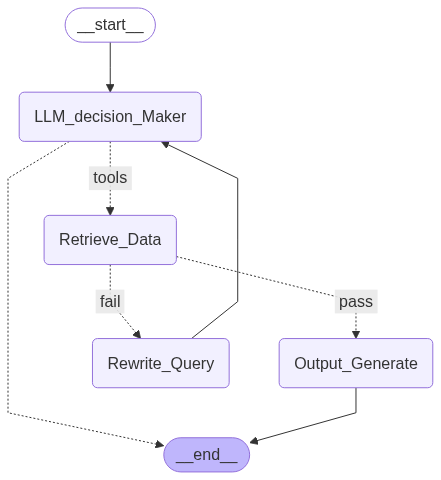

In [141]:
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
builder = StateGraph(State)

builder.add_node("LLM_decision_Maker", llm_decision_maker)
builder.add_node("Retrieve_Data", retriever_node)
builder.add_node("Output_Generate", output_generator)
builder.add_node("Rewrite_Query", rewrite_query)

## edge define
builder.add_edge(START, "LLM_decision_Maker")
builder.add_conditional_edges(
    "LLM_decision_Maker",
    tools_condition,
    {
        "tools": "Retrieve_Data",
        END: END
    }
)
builder.add_conditional_edges(
    "Retrieve_Data",
    grade_docs,
    {
        "pass": "Output_Generate",
        "fail": "Rewrite_Query"
    }
)
builder.add_edge("Output_Generate", END)
builder.add_edge("Rewrite_Query", "LLM_decision_Maker")

graph = builder.compile()

from IPython.display import display,Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [146]:
# output = graph.invoke(
#     {
#         "messages": ["what is LLM Powered Autonomous Agents explain the planning and reflection and prompt engineering explain me in terms of agents and langchain? "]
#     }
# )
input = {
        "messages": ["what is LLM Powered Autonomous Agents explain the planning and reflection and prompt engineering explain me in terms of agents and langchain? "]
    }

for event in graph.stream(input, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

what is LLM Powered Autonomous Agents explain the planning and reflection and prompt engineering explain me in terms of agents and langchain? 
--Call LLM decision maker---
================================== Ai Message ==================================
Tool Calls:
  all about autonomous agent (eq9z1mfqp)
 Call ID: eq9z1mfqp
  Args:
    query: LLM Powered Autonomous Agents planning and reflection and prompt engineering in terms of agents and langchain
---grade docs---
pass
----DECISION: DOCS ARE RELEVANT----
================================= Tool Message =================================
Name: all about autonomous agent

LLM Powered Autonomous Agents | Lil'Log







































Lil'Log

















|






Posts




Archive




Search




Tags




FAQ









      LLM Powered Autonomous Agents
    
Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng


 

In [143]:
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000001A9A0E648C0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001A9A100D370>, model_name='meta-llama/llama-4-scout-17b-16e-instruct', temperature=0.6, model_kwargs={}, groq_api_key=SecretStr('**********'))